# Pulsed microwave spectrum test

Drives the microwave source CW at a fixed power, gates it on/off through AWG CH2 (a 50% duty cycle square wave at `1 / period_ns`, same TTL-into-the-switch convention as `rf_switch_test.ipynb`), and captures the resulting comb spectrum on the E4403B.

Edit `PERIOD_NS` in the "run" cell below and re-run it to try a different pulse period -- everything else (connections, functions) only needs to run once. Each run saves `freqs_hz.npy`, `power_dbm.npy`, and `metadata.txt` to its own subfolder under `data/`, named by the period.

**Check your physical routing before running**: at 0 dBm drive, confirm where the switch output actually goes (straight to the analyzer vs. through the amplifier first) -- 0 dBm direct into the analyzer is fine, but 0 dBm through the amplifier could exceed the analyzer's input damage level. See `rf_switch_test.ipynb`'s power-budget cell for how to check this if the amplifier is in the chain.

In [44]:
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# This notebook lives in experiment/tests/ -- the driver modules
# (ks33600a.py, hp8673h.py, e4403b.py) are one level up, in
# experiment/ itself.
sys.path.insert(0, r"C:\Users\codin\Documents\projects\diamonds\experiment")

import ks33600a
from hp8673h import HP8673H
from e4403b import E4403B

AWG_RESOURCE = "USB0::0x0957::0x5707::MY53800810::INSTR"
GEN_RESOURCE = "GPIB1::19::INSTR"
SA_RESOURCE = "GPIB0::18::INSTR"

TESTS_DIR = Path(r"C:\Users\codin\Documents\projects\diamonds\experiment\tests")
DATA_DIR = TESTS_DIR / "data"

CARRIER_HZ = 2.5e9  # adjust to whatever carrier frequency this test should use

awg = ks33600a.KS33600A(AWG_RESOURCE, debug=True)
sa = E4403B(SA_RESOURCE)
gen = HP8673H(GEN_RESOURCE)

Keysight 33600A: connected
*RST => +0,"No error"
*CLS => +0,"No error"
SOUR1:DATA:VOL:CLE => +0,"No error"
SOUR2:DATA:VOL:CLE => +0,"No error"
E4403B: connected
HP8673H: connected


## Functions

In [45]:
def setup_pulse_gate(awg, period_ns, duty_cycle_pct=50.0):
    """Configure AWG CH2 as a free-running square wave gate, period_ns period,
    0-5V into a high-Z load (the switch's control input)."""
    chop_freq_hz = 1.0 / (period_ns * 1e-9)
    awg.write("SOUR2:FUNC SQU")
    awg.write(f"SOUR2:FUNC:SQU:DCYCle {duty_cycle_pct}")
    awg.write(f"SOUR2:FREQ {chop_freq_hz}")
    awg.write("OUTP2:LOAD INF")
    awg.write("SOUR2:VOLT:UNIT VPP")
    awg.write("SOUR2:VOLT 5.0")
    awg.write("SOUR2:VOLT:OFFS 2.5")
    awg.write("TRIG2:SOUR IMM")
    awg.write("OUTPUT2 ON")
    return chop_freq_hz


def setup_cw_carrier(gen, carrier_hz, drive_power_dbm):
    """Set the microwave source to CW at carrier_hz / drive_power_dbm, RF on."""
    gen.preset()
    gen.set_frequency_hz(carrier_hz)
    gen.set_power_dbm(drive_power_dbm)
    gen.rf_on()


def capture_spectrum(sa, carrier_hz, chop_freq_hz, n_sidebands=20, averages=10):
    """Span wide enough to see n_sidebands each side of the carrier, RBW well
    below the chop frequency spacing. Returns (freqs_hz, power_dbm)."""
    span_hz = 2 * n_sidebands * chop_freq_hz
    rbw_hz = chop_freq_hz / 20
    sa.set_center_span(carrier_hz, span_hz)
    sa.write(f"BAND {rbw_hz}")
    sa.setup_averaging(count=averages)
    sa.single_sweep(n=averages)
    freqs_hz, power_dbm = sa.get_trace(1)
    return freqs_hz, power_dbm, span_hz, rbw_hz


def save_pulsed_spectrum(data_dir, period_ns, freqs_hz, power_dbm, metadata):
    run_dir = data_dir / f"pulse_{period_ns:g}ns"
    run_dir.mkdir(parents=True, exist_ok=True)
    np.save(run_dir / "freqs_hz.npy", freqs_hz)
    np.save(run_dir / "power_dbm.npy", power_dbm)
    with open(run_dir / "metadata.txt", "w") as fh:
        for key, value in metadata.items():
            fh.write(f"{key}={value}\n")
    return run_dir


def run_pulsed_spectrum_test(
    period_ns,
    drive_power_dbm=0.0,
    carrier_hz=CARRIER_HZ,
    duty_cycle_pct=50.0,
    n_sidebands=10,
    data_dir=DATA_DIR,
):
    """Configure the pulse gate + carrier, capture the spectrum, and save it.
    Returns (freqs_hz, power_dbm, run_dir)."""
    chop_freq_hz = setup_pulse_gate(awg, period_ns, duty_cycle_pct)
    setup_cw_carrier(gen, carrier_hz, drive_power_dbm)
    freqs_hz, power_dbm, span_hz, rbw_hz = capture_spectrum(
        sa, carrier_hz, chop_freq_hz, n_sidebands
    )

    metadata = {
        "period_ns": period_ns,
        "chop_freq_hz": chop_freq_hz,
        "duty_cycle_pct": duty_cycle_pct,
        "drive_power_dbm": drive_power_dbm,
        "carrier_hz": carrier_hz,
        "span_hz": span_hz,
        "rbw_hz": rbw_hz,
        "timestamp": datetime.now().isoformat(),
    }
    run_dir = save_pulsed_spectrum(data_dir, period_ns, freqs_hz, power_dbm, metadata)

    print(
        f"{period_ns} ns period ({chop_freq_hz/1e6:.3f} MHz), "
        f"{duty_cycle_pct:.0f}% duty, {drive_power_dbm:+.1f} dBm carrier: "
        f"captured {len(freqs_hz)} points, saved to {run_dir}"
    )
    return freqs_hz, power_dbm, run_dir


def plot_pulsed_spectrum(freqs_hz, power_dbm, carrier_hz, title=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot((freqs_hz - carrier_hz) / 1e6, power_dbm)
    ax.set_xlabel("frequency - carrier [MHz]")
    ax.set_ylabel("power [dBm]")
    if title:
        ax.set_title(title)
    plt.show()
    return fig, ax

## Run

Edit `PERIOD_NS` and re-run this cell (and the plot cell below it) for each period you want to try.

In [74]:
PERIOD_NS = 27

freqs_hz, power_dbm, run_dir = run_pulsed_spectrum_test(PERIOD_NS)

SOUR2:FUNC SQU => +0,"No error"
SOUR2:FUNC:SQU:DCYCle 50.0 => +0,"No error"
SOUR2:FREQ 37037037.03703704 => +0,"No error"
OUTP2:LOAD INF => +0,"No error"
SOUR2:VOLT:UNIT VPP => +0,"No error"
SOUR2:VOLT 5.0 => +0,"No error"
SOUR2:VOLT:OFFS 2.5 => +0,"No error"
TRIG2:SOUR IMM => +0,"No error"
OUTPUT2 ON => +0,"No error"
27 ns period (37.037 MHz), 50% duty, +0.0 dBm carrier: captured 401 points, saved to C:\Users\codin\Documents\projects\diamonds\experiment\tests\data\pulse_27ns


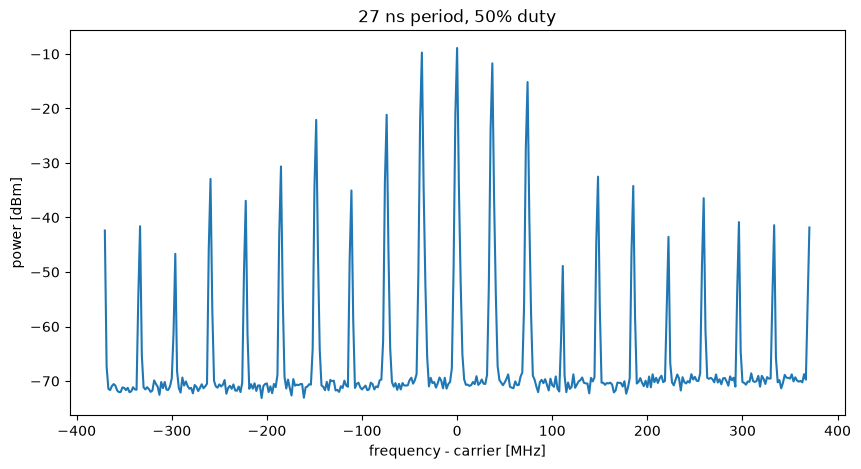

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': '27 ns period, 50% duty'}, xlabel='frequency - carrier [MHz]', ylabel='power [dBm]'>)

In [75]:
plot_pulsed_spectrum(
    freqs_hz, power_dbm, CARRIER_HZ, title=f"{PERIOD_NS} ns period, 50% duty"
)

## Shutdown

In [43]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()
awg.write("OUTPUT2 OFF")
awg.close()

OUTPUT2 OFF => +0,"No error"
